## Name : Rajkumar Rajak
## Scholar No: 25215011118

## **Lab 4 : Human Activity Recognition using WISDM dataset and self attention mechanism**   

## Objective:
To implement a Transformer-inspired sliding window self-attention model for classifying human
activities using wearable sensor data.

## Datasets:
WISDM (Accelerometer, 20 Hz) and DADS (Accelerometer & Gyroscope) datasets for daily-life
activities.
Software/Tools:
Python, NumPy, Pandas, Matplotlib (optional: PyTorch/TensorFlow).

## Procedure (5 Steps):
1. Load and explore WISDM and DADS datasets and visualize sample activities.
2. Preprocess sensor data using noise removal, normalization, and label encoding.
3. Segment the data into overlapping sliding windows (128 samples, 50% overlap).
4. Apply window-based self-attention using a Transformer encoder to extract features.
5. Classify activities and evaluate performance using accuracy and F1-score.  

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, LayerNormalization, MultiHeadAttention, GlobalAveragePooling1D
from tensorflow.keras.models import Model


In [ ]:
import pandas as pd

columns = ['user','activity','timestamp','x','y','z']

data = pd.read_csv(
    '/content/WISDM_ar_v1.1_raw.txt',
    header=None,
    names=columns,
    sep=',',
    engine='python',
    on_bad_lines='skip'
)

print("Loaded data shape:", data.shape)
data.head()

Loaded data shape: (1086466, 6)


,user,activity,timestamp,x,y,z
0,33,Jogging,49105962326000,-0.694638,12.680544,0.50395286;
1,33,Jogging,49106062271000,5.012288,11.264028,0.95342433;
2,33,Jogging,49106112167000,4.903325,10.882658,-0.08172209;
3,33,Jogging,49106222305000,-0.612916,18.496431,3.0237172;
4,33,Jogging,49106332290000,-1.184970,12.108489,7.205164;


In [ ]:
# Remove semicolon from z column
data["z"] = data["z"].astype(str).str.replace(";", "", regex=False)
data["z"] = pd.to_numeric(data["z"], errors="coerce")

# Drop any bad rows
data = data.dropna()

print(data.dtypes)


user           int64
activity      object
timestamp      int64
x            float64
y            float64
z            float64
dtype: object


In [ ]:
data.isna().sum()


,0
user,0
activity,0
timestamp,0
x,0
y,0
z,0


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
data["activity"] = le.fit_transform(data["activity"])


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
data[["x","y","z"]] = scaler.fit_transform(data[["x","y","z"]])


In [ ]:
import numpy as np

def sliding_window(df, window=128, step=64):
    X, y = [], []
    for i in range(0, len(df) - window, step):
        X.append(df[["x","y","z"]].iloc[i:i+window].values)
        y.append(df["activity"].iloc[i+window])
    return np.array(X), np.array(y)

X, y = sliding_window(data)
print(X.shape, y.shape)


(16975, 128, 3) (16975,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Dense, LayerNormalization,
    MultiHeadAttention, GlobalAveragePooling1D
)
from tensorflow.keras.models import Model
from sklearn.metrics import accuracy_score, f1_score
import numpy as np


In [ ]:
from tensorflow.keras.layers import Dense, LayerNormalization, MultiHeadAttention

def transformer_encoder(inputs, embed_dim=64, num_heads=4):
    # Project input from (128,3) → (128,64)
    x = Dense(embed_dim)(inputs)

    # Self-attention
    attn = MultiHeadAttention(
        num_heads=num_heads,
        key_dim=embed_dim
    )(x, x)

    # Residual + Norm
    x = LayerNormalization(epsilon=1e-6)(x + attn)

    # Feed-forward
    ff = Dense(embed_dim, activation="relu")(x)

    # Residual + Norm
    return LayerNormalization(epsilon=1e-6)(x + ff)


In [ ]:
def transformer_decoder(dec_inputs, enc_outputs, embed_dim=64, num_heads=4):
    # Self-attention on decoder input
    attn1 = MultiHeadAttention(
        num_heads=num_heads,
        key_dim=embed_dim
    )(dec_inputs, dec_inputs)

    x = LayerNormalization(epsilon=1e-6)(dec_inputs + attn1)

    # Cross-attention with encoder output
    attn2 = MultiHeadAttention(
        num_heads=num_heads,
        key_dim=embed_dim
    )(x, enc_outputs)

    x = LayerNormalization(epsilon=1e-6)(x + attn2)

    # Feed-forward
    ff = Dense(embed_dim, activation="relu")(x)

    return LayerNormalization(epsilon=1e-6)(x + ff)

In [ ]:
num_classes = len(np.unique(y_train))

inputs = Input(shape=(128, 3))

# Encoder
enc_output = transformer_encoder(inputs)

# Decoder (use encoder output as both decoder input and memory)
dec_output = transformer_decoder(enc_output, enc_output)

# Pooling
x = GlobalAveragePooling1D()(dec_output)

# Classification Head
x = Dense(64, activation="relu")(x)
outputs = Dense(num_classes, activation="softmax")(x)

model = Model(inputs, outputs)

model = Model(inputs, outputs)

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 3)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128, 64)   │        256 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 128, 64)   │     66,368 │ dense[0][0],      │
│ (MultiHeadAttentio… │                   │            │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 128, 64)   │          0 │ dense[0][0],      │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 128, 64)   │        128 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128, 64)   │      4,160 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 128, 64)   │          0 │ layer_normalizat… │
│                     │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 128, 64)   │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 128, 64)   │     66,368 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 128, 64)   │          0 │ layer_normalizat… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 128, 64)   │        128 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 128, 64)   │     66,368 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 128, 64)   │          0 │ layer_normalizat… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 128, 64)   │        128 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128, 64)   │      4,160 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 128, 64)   │          0 │ layer_normalizat… │
│                     │                   │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 128, 64)   │        128 │ add_4[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ layer_normalizat

 Total params: 212,870 (831.52 KB)

 Trainable params: 212,870 (831.52 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)


Epoch 1/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 24s 63ms/step - accuracy: 0.7196 - loss: 0.8494 - val_accuracy: 0.8339 - val_loss: 0.4391
Epoch 2/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.8523 - loss: 0.4276 - val_accuracy: 0.8748 - val_loss: 0.3392
Epoch 3/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.8826 - loss: 0.3463 - val_accuracy: 0.9175 - val_loss: 0.2559
Epoch 4/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.9113 - loss: 0.2726 - val_accuracy: 0.9230 - val_loss: 0.2348
Epoch 5/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9187 - loss: 0.2406 - val_accuracy: 0.9227 - val_loss: 0.2416
Epoch 6/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.9255 - loss: 0.2204 - val_accuracy: 0.9293 - val_loss: 0.2243
Epoch 7/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.9326 - loss: 0.1986 - val_accuracy: 0.9396 - val_loss: 0.1958
Epoch 8/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.9414 - loss: 0.1887 - val_acc

107/107 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step
Test Accuracy: 94.16789412498474 %


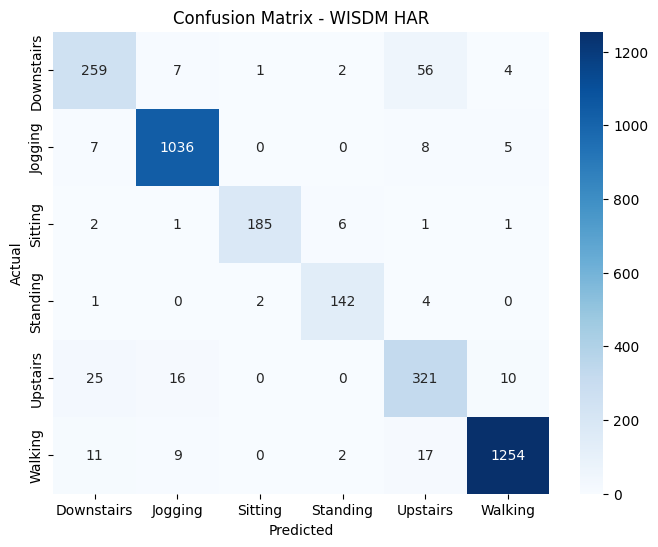

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = np.argmax(model.predict(X_test), axis=1)
cm = confusion_matrix(y_test, y_pred)

loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print("Test Accuracy:", accuracy * 100, "%")

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - WISDM HAR')
plt.show()